# XAI Contestation: English Translation and Feasibility Audit

This is **notebook 02**. It follows `01_data_inventory_and_feasibility_audit.ipynb`,
which only *inventoried* the XAI-FUNGI dataset. Here we do the two things the
project actually needs before any taxonomy or annotation work begins:

1. **Translate the Polish transcript text to English.** Annotation and modelling
   still operate on the original Polish (see the proposal), but an English
   `text_en` column makes the feasibility audit, codebook drafting, and quoting
   tractable for an English-working team and reviewers.

2. **Run the real feasibility audit** — the *evidence gate*. We locate candidate
   contestation episodes cheaply by reusing the dataset's existing thematic codes
   (`MAXQDA_SUMMARY` + `CODEBOOK`) and a bilingual lexical pass, then export a
   stratified sample for manual review. The output is an honest count of how many
   *genuine* contestation episodes exist and how diverse they are, which decides
   whether the paper keeps "contestation" as its central construct or widens to
   "epistemic friction".

**Data governance.** Translation defaults to a **local, offline** model
(`Helsinki-NLP/opus-mt-pl-en`) so anonymized participant transcripts never leave
the machine. Do **not** switch to an external MT API (DeepL, Google, a hosted LLM)
without first confirming the dataset licence and original consent permit it — this
is the ethics constraint stated in the proposal. No original dataset files are
modified by this notebook.

In [13]:
# ============================================================
# 1. Libraries, configuration, and project paths
# ============================================================

from __future__ import annotations

import hashlib
import logging
import random
import re
import warnings
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd
from IPython.display import display

try:
    import matplotlib.pyplot as plt
    _HAVE_MPL = True
except Exception:  # noqa: BLE001
    _HAVE_MPL = False

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 250)
pd.set_option("display.width", 160)

warnings.filterwarnings("default", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
LOGGER = logging.getLogger("xai_contestation")


# ------------------------------------------------------------
# Locate the project root automatically
# ------------------------------------------------------------

def find_project_root(start_path: Path | None = None) -> Path:
    """Find the project root by searching upward for a data/ folder."""
    start = (Path.cwd() if start_path is None else Path(start_path)).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root (a parent containing data/)."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
TRANSCRIPTS_DIR = DATA_DIR / "transcripts"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "02_translation_and_feasibility_audit"
TABLE_OUTPUT_DIR = OUTPUT_DIR / "tables"
FIGURE_OUTPUT_DIR = OUTPUT_DIR / "figures"
TRANSLATION_DIR = OUTPUT_DIR / "translations"

for directory in (TABLE_OUTPUT_DIR, FIGURE_OUTPUT_DIR, TRANSLATION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Translation configuration
# ------------------------------------------------------------

# Local, offline PL->EN model. Keeps participant data on-premise.
# NLLB-200 is markedly more fluent than opus-mt and preserves clauses that
# opus-mt silently drops -- which is what contestation coding depends on. It
# still mistranslates rare mycology nouns (e.g. "muchomor" -> "mosquito"), so
# any quoted species term must be checked against the Polish. For full domain
# fidelity, an LLM translation with a glossary is the upgrade. Lighter,
# lower-quality fallback: "Helsinki-NLP/opus-mt-pl-en".
TRANSLATION_MODEL = "facebook/nllb-200-distilled-600M"
NLLB_SRC_LANG = "pol_Latn"    # applied only to NLLB-family models
NLLB_TGT_LANG = "eng_Latn"
# Cache is keyed to the model, so switching models never reuses old output.
_MODEL_TAG = TRANSLATION_MODEL.split("/")[-1].replace("-", "_")
TRANSLATION_CACHE = TRANSLATION_DIR / f"{_MODEL_TAG}_pl_en_cache.parquet"
TRANSLATION_BATCH_SIZE = 16   # NLLB is larger; smaller batches are safer on CPU
TRANSLATION_MAX_CHARS = 400   # sentence-pack budget per model call
# Set True only after confirming licence/consent allow external services.
ALLOW_EXTERNAL_MT = False

LOGGER.info("Project root: %s", PROJECT_ROOT)
LOGGER.info("Output directory: %s", OUTPUT_DIR)
LOGGER.info("Translation model (local): %s", TRANSLATION_MODEL)

INFO | Project root: /Users/sabrimanai/software/uj/detecting-contestation-xai
INFO | Output directory: /Users/sabrimanai/software/uj/detecting-contestation-xai/outputs/02_translation_and_feasibility_audit
INFO | Translation model (local): facebook/nllb-200-distilled-600M


In [14]:
# ============================================================
# 2. Reusable loaders (shared with notebook 01)
# ============================================================

def read_csv_robust(path: Path) -> pd.DataFrame:
    """Load a CSV, trying encodings common in Polish-language data."""
    encodings = ("utf-8-sig", "utf-8", "cp1250", "windows-1250", "latin1")
    errors: list[str] = []
    for encoding in encodings:
        try:
            df = pd.read_csv(path, encoding=encoding, sep=None, engine="python")
            df.columns = [str(c).strip() for c in df.columns]
            return df
        except (UnicodeDecodeError, pd.errors.ParserError) as error:
            errors.append(f"{encoding}: {error}")
    raise ValueError(
        f"Could not read CSV file: {path}\nAttempted:\n" + "\n".join(errors)
    )


def normalise_empty_strings(df: pd.DataFrame) -> pd.DataFrame:
    """Convert empty / whitespace-only string cells to pandas NA."""
    result = df.copy()
    for column in result.select_dtypes(include=["object", "string"]).columns:
        result[column] = result[column].replace(r"^\s*$", pd.NA, regex=True)
    return result

## Transcript loading with merged-file handling

Notebook 01 counted **38 transcript files** and grouped them by file, which made
the domain-expert (DE) group look like 12 participants. In fact one file,
`PK_DE_11-12.csv`, contains **two** merged participants. Accounting for that:

| Group | Files | Participants |
|-------|-------|--------------|
| DE (mycology experts) | 12 | **13** |
| IT (data science / viz) | 8 | 8 |
| SSH (social sci / humanities) | 18 | 18 |
| **Total** | **38** | **39** |

So the manuscript's "39 participants / 13 experts" is correct. We record a
`__participant_count` field (2 for the merged file, 1 otherwise) and flag the file
so downstream participant-level benchmark splits treat it as a known caveat — the
two participants cannot be cleanly separated without a boundary marker in the
transcript.

In [15]:
# ============================================================
# 3. Load and combine transcripts (merged-file aware)
# ============================================================

MERGED_FILES = {"PK_DE_11-12": 2}   # file stem -> number of participants


def extract_transcript_metadata(path: Path) -> dict[str, Any]:
    """Metadata inferred from a filename such as DR_IT_05.csv / PK_DE_11-12.csv."""
    stem = path.stem
    parts = stem.split("_")
    group_match = re.search(r"_(DE|IT|SSH)_", f"_{stem}_")
    case_match = re.search(r"(\d+(?:-\d+)?)$", stem)
    return {
        "__source_file": path.name,
        "__transcript_id": stem,
        "__source_prefix": parts[0] if parts else pd.NA,
        "__participant_group": group_match.group(1) if group_match else pd.NA,
        "__case_number": case_match.group(1) if case_match else pd.NA,
        "__participant_count": MERGED_FILES.get(stem, 1),
        "__is_merged_file": stem in MERGED_FILES,
    }


transcript_paths = sorted(TRANSCRIPTS_DIR.glob("*.csv"))
frames: list[pd.DataFrame] = []

for path in transcript_paths:
    tr = normalise_empty_strings(read_csv_robust(path))
    tr.insert(0, "__row_in_file", np.arange(1, len(tr) + 1))
    for position, (column, value) in enumerate(extract_transcript_metadata(path).items()):
        tr.insert(position, column, value)
    frames.append(tr)

transcripts = pd.concat(frames, ignore_index=True, sort=False)

# A stable per-row episode id, useful for candidate export and later annotation.
transcripts["__utt_id"] = (
    transcripts["__transcript_id"].astype(str)
    + ":"
    + transcripts["__row_in_file"].astype(str)
)

LOGGER.info("Loaded %d transcript files, %d rows.",
            transcripts["__source_file"].nunique(), len(transcripts))
display(transcripts.head(3))

INFO | Loaded 38 transcript files, 14835 rows.


,__source_file,__transcript_id,__source_prefix,__participant_group,__case_number,__participant_count,__is_merged_file,__row_in_file,speaker_id,slide_id,question_id,problem_id,text,__utt_id
0,DR_IT_05.csv,DR_IT_05,DR,IT,05,1,False,1,DR,NaN,NaN,NaN,"Transkrypcja została włączona i ona sobie tutaj to spotkanie będzie sobie szło w tle ja z minimalizuję okno, żeby ono pani nie rozpraszało. Jednocześnie włączę tryb nagrywania w telefonie.",DR_IT_05:1
1,DR_IT_05.csv,DR_IT_05,DR,IT,05,1,False,2,DR,NaN,NaN,NaN,Tak mamy.,DR_IT_05:2
2,DR_IT_05.csv,DR_IT_05,DR,IT,05,1,False,3,DR,NaN,NaN,NaN,"I zrobimy może w ten sposób, że ja panią zaproszę tutaj na to stanowisko.",DR_IT_05:3


In [16]:
# ============================================================
# 4. Participant / file reconciliation
# ============================================================

reconciliation = (
    transcripts.groupby("__participant_group")
    .agg(
        files=("__source_file", "nunique"),
        rows=("__source_file", "size"),
        participants=("__source_file",
                      lambda s: transcripts.loc[s.index]
                      .drop_duplicates("__source_file")["__participant_count"].sum()),
    )
    .reset_index()
    .sort_values("__participant_group")
)

total_files = int(reconciliation["files"].sum())
total_participants = int(reconciliation["participants"].sum())

print("Files vs participants by group:")
display(reconciliation)
print(f"TOTAL files={total_files}  participants={total_participants}")

assert total_files == 38, f"expected 38 files, got {total_files}"
assert total_participants == 39, f"expected 39 participants, got {total_participants}"
assert int(reconciliation.loc[reconciliation['__participant_group'] == 'DE',
                              'participants'].iloc[0]) == 13, "DE should be 13 participants"

reconciliation.to_csv(TABLE_OUTPUT_DIR / "participant_reconciliation.csv", index=False)
LOGGER.info("Reconciliation matches manuscript (39 participants, 13 DE experts).")

Files vs participants by group:


,__participant_group,files,rows,participants
0,DE,12,1960,13
1,IT,8,3445,8
2,SSH,18,9430,18


INFO | Reconciliation matches manuscript (39 participants, 13 DE experts).


TOTAL files=38  participants=39


## Translation (Polish -> English)

We translate only the unique, non-empty transcript utterances (~14k rows collapse
to far fewer unique strings), cache them to disk keyed by a content hash, and add
a `text_en` column. Re-running is cheap because cached translations are reused.

**Model.** `Helsinki-NLP/opus-mt-pl-en` runs fully offline via `transformers`.
Long utterances are split into sentence-sized chunks so they fit the model's
input limit, then re-joined. If the translation stack is not installed the notebook
prints install instructions and continues without a `text_en` column, so the audit
below still runs on the Polish text and the existing English codes.

```bash
pip install "transformers>=4.40" "torch" "sentencepiece" "sacremoses"
```

In [17]:
# ============================================================
# 5. Translation engine (local, cached, idempotent)
# ============================================================

def _hash_text(text: str) -> str:
    return hashlib.sha1(text.encode("utf-8")).hexdigest()


def _sentence_chunks(text: str, max_chars: int = TRANSLATION_MAX_CHARS) -> list[str]:
    """One chunk per sentence. opus-mt is a sentence-level model and drops
    clauses when several sentences share a call, so we translate each sentence
    separately (still batched for speed) and hard-split any over max_chars."""
    sentences = re.split(r"(?<=[.!?\u2026])\s+", str(text).strip())
    chunks: list[str] = []
    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
        if len(sentence) > max_chars:  # hard-split very long sentences
            for i in range(0, len(sentence), max_chars):
                chunks.append(sentence[i:i + max_chars])
        else:
            chunks.append(sentence)
    return chunks or [str(text)]


def load_translation_cache() -> dict[str, str]:
    if TRANSLATION_CACHE.exists():
        cached = pd.read_parquet(TRANSLATION_CACHE)
        LOGGER.info("Loaded %d cached translations.", len(cached))
        return dict(zip(cached["hash"], cached["text_en"]))
    return {}


def save_translation_cache(cache: dict[str, str]) -> None:
    pd.DataFrame({"hash": list(cache), "text_en": list(cache.values())}) \
        .to_parquet(TRANSLATION_CACHE, index=False)


def build_translator() -> Callable[[list[str]], list[str]] | None:
    """Return a batch translate function, or None if the stack is unavailable.

    Drives AutoModelForSeq2SeqLM.generate() directly rather than the
    transformers "translation" pipeline, which was removed in transformers 5.x.
    """
    try:
        import torch
        from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
    except Exception as error:  # noqa: BLE001
        LOGGER.warning(
            "Translation stack unavailable (%s). Skipping translation.\n"
            "Install: pip install transformers torch sentencepiece sacremoses",
            error,
        )
        return None

    device = "cuda" if torch.cuda.is_available() else "cpu"
    LOGGER.info("Loading %s on %s ...", TRANSLATION_MODEL, device.upper())
    tokenizer = AutoTokenizer.from_pretrained(TRANSLATION_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(TRANSLATION_MODEL).to(device).eval()

    # NLLB needs the source language set on the tokenizer and the target
    # language forced as the first generated token.
    is_nllb = "nllb" in TRANSLATION_MODEL.lower()
    forced_bos = None
    if is_nllb:
        tokenizer.src_lang = NLLB_SRC_LANG
        forced_bos = tokenizer.convert_tokens_to_ids(NLLB_TGT_LANG)

    def translate_batch(texts: list[str]) -> list[str]:
        encoded = tokenizer(texts, return_tensors="pt", padding=True,
                            truncation=True, max_length=512).to(device)
        gen_kwargs = {"max_length": 512, "num_beams": 4}
        if forced_bos is not None:
            gen_kwargs["forced_bos_token_id"] = forced_bos
        with torch.no_grad():
            generated = model.generate(**encoded, **gen_kwargs)
        return tokenizer.batch_decode(generated, skip_special_tokens=True)

    return translate_batch


def translate_series(texts: pd.Series) -> pd.Series:
    """Translate a Series of Polish strings to English, using the disk cache."""
    cache = load_translation_cache()
    unique_texts = sorted({t for t in texts.dropna().astype(str) if t.strip()})
    hashes = {t: _hash_text(t) for t in unique_texts}
    missing = [t for t in unique_texts if hashes[t] not in cache]
    LOGGER.info("%d unique utterances; %d already cached; %d to translate.",
                len(unique_texts), len(unique_texts) - len(missing), len(missing))

    translator = build_translator() if missing else (lambda x: x)
    if translator is None:   # stack unavailable -> no text_en
        return pd.Series(pd.NA, index=texts.index, dtype="string")

    # Flatten to chunks, translate, then reassemble per source utterance.
    for start in range(0, len(missing), TRANSLATION_BATCH_SIZE):
        batch = missing[start:start + TRANSLATION_BATCH_SIZE]
        chunk_lists = [_sentence_chunks(t) for t in batch]
        flat = [c for chunks in chunk_lists for c in chunks]
        translated_flat = translator(flat)
        pos = 0
        for source, chunks in zip(batch, chunk_lists):
            n = len(chunks)
            cache[hashes[source]] = " ".join(translated_flat[pos:pos + n]).strip()
            pos += n
        if (start // TRANSLATION_BATCH_SIZE) % 10 == 0:
            LOGGER.info("Translated %d / %d ...", min(start + TRANSLATION_BATCH_SIZE,
                        len(missing)), len(missing))
            save_translation_cache(cache)

    save_translation_cache(cache)
    return texts.map(lambda t: cache.get(_hash_text(str(t)), pd.NA)
                     if pd.notna(t) and str(t).strip() else pd.NA).astype("string")

In [18]:
# ============================================================
# 6. Apply translation and export a bilingual transcript table
# ============================================================

transcripts["text_en"] = translate_series(transcripts["text"])

n_translated = int(transcripts["text_en"].notna().sum())
LOGGER.info("Attached English text to %d / %d rows.", n_translated, len(transcripts))

bilingual_cols = [
    "__utt_id", "__transcript_id", "__participant_group", "__participant_count",
    "__row_in_file", "speaker_id", "slide_id", "question_id", "problem_id",
    "text", "text_en",
]
bilingual = transcripts[bilingual_cols].copy()
bilingual.to_parquet(OUTPUT_DIR / "transcripts_bilingual.parquet", index=False)
bilingual.to_csv(OUTPUT_DIR / "transcripts_bilingual.csv", index=False)

if n_translated:
    display(bilingual.loc[bilingual["text_en"].notna(),
                          ["__utt_id", "text", "text_en"]].head(8))
else:
    print("No translations attached (stack unavailable). Audit continues on Polish text.")

INFO | Loaded 3 cached translations.
INFO | 13861 unique utterances; 0 already cached; 13861 to translate.
/Users/sabrimanai/software/uj/detecting-contestation-xai/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO | Loading facebook/nllb-200-distilled-600M on CPU ...
INFO | HTTP Request: HEAD https://huggingface.co/facebook/nllb-200-distilled-600M/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/nllb-200-distilled-600M/f8d333a098d19b4fd9a8b18f94170487ad3f821d/config.json "HTTP/1.1 200 OK"
INFO | HTTP Request: HEAD https://huggingface.co/facebook/nllb-200-dis

,__utt_id,text,text_en
0,DR_IT_05:1,"Transkrypcja została włączona i ona sobie tutaj to spotkanie będzie sobie szło w tle ja z minimalizuję okno, żeby ono pani nie rozpraszało. Jednocześnie włączę tryb nagrywania w telefonie.","The transcript has been turned on and she's going to have this meeting going on in the background and I'm going to minimize the window so it doesn't distract you. At the same time, I'll turn on the recording mode on the phone."
1,DR_IT_05:2,Tak mamy.,That's what we've got.
2,DR_IT_05:3,"I zrobimy może w ten sposób, że ja panią zaproszę tutaj na to stanowisko.",And we'll do it this way that I invite you here for this position.
3,DR_IT_05:4,Około pani.,Around you.
4,DR_IT_05:5,Wszystko jest w porządku.,It's all right. It's all right.
5,DR_IT_05:6,Daję pani kod badania. badanie jest anonimizowane.,I'll give you the test code. the test is anonymised.
6,DR_IT_05:7,I teraz tak.,And now it is.
7,DR_IT_05:8,"Zgodnie tutaj z zasadami z wytycznymi prowadzenia badań informuję panią, że nasze badanie jest zarejestrowane w trybie audio to badanie jest kontynuacją ankiety, którą pani wypełniała i będziemy panią badać za pomocą protokołu. To.","In accordance with the guidelines for conducting the survey here, I would like to inform you that our study is recorded in audio mode. This study is a continuation of the survey you completed, and we will study you using the protocol. This one."


## Feasibility audit

The audit surfaces **candidate** contestation episodes from two cheap signals, then
relies on **manual review** of a stratified sample for the real verdict. Nothing
here claims automated detection of genuine contestation — the lexicon and code
filters over-generate on purpose, so the manual pass measures precision.

**Signal A — existing thematic codes.** `MAXQDA_SUMMARY` gives, per participant and
per explanation method, counts of the 82 dataset codes. Several are
contestation-adjacent and map onto the taxonomy's *target* / *grounds* dimensions.

**Signal B — bilingual lexical pass.** Challenge markers vs. incomprehension
markers over the transcript text (Polish, plus English where available), to
operationalise the load-bearing contestation/incomprehension boundary.

In [19]:
# ============================================================
# 7. Signal A: contestation-adjacent existing codes
# ============================================================

codebook = normalise_empty_strings(read_csv_robust(DATA_DIR / "CODEBOOK.csv"))
maxqda = normalise_empty_strings(read_csv_robust(DATA_DIR / "MAXQDA_SUMMARY.csv"))

# Provisional mapping of existing codes -> taxonomy dimension. Refine after audit.
CONTESTATION_ADJACENT_CODES = {
    "negative reception": "grounds/attitude",
    "methods of analysis > difficulties": "target: explanation representation",
    "methods of analysis > discrepancies": "grounds: internal inconsistency",
    "methods of analysis > ai hypotheses": "target: reasoning",
    "expectations": "grounds: violated expectation",
    "expectations > biotope": "grounds: domain knowledge",
    "expectations > macroscopic features": "grounds: domain knowledge",
    "expectations > organoleptic features": "grounds: domain knowledge",
    "barriers > concerns": "target: system competence",
    "personification": "target: epistemic authority",
    "affects > overwhelming > uncertainty": "act: acknowledge uncertainty",
}

method_columns = [c for c in maxqda.columns if c not in ("code", "participant_id")]
adjacent = maxqda[maxqda["code"].isin(CONTESTATION_ADJACENT_CODES)].copy()
adjacent["total_hits"] = adjacent[method_columns].sum(axis=1)

# Coded segments per adjacent code x explanation method (the cheap heat-map).
code_by_method = (
    adjacent.groupby("code")[method_columns].sum()
    .assign(TOTAL=lambda d: d.sum(axis=1))
    .sort_values("TOTAL", ascending=False)
)
print("Contestation-adjacent coded segments by explanation method:")
display(code_by_method)
code_by_method.to_csv(TABLE_OUTPUT_DIR / "adjacent_codes_by_method.csv")

# Which participants carry the most adjacent-coded material.
per_participant = (
    adjacent.groupby("participant_id")["total_hits"].sum()
    .sort_values(ascending=False).rename("adjacent_code_hits")
)
display(per_participant.head(15).to_frame())
per_participant.to_frame().to_csv(TABLE_OUTPUT_DIR / "adjacent_codes_by_participant.csv")

Contestation-adjacent coded segments by explanation method:


,descriptive statistics,counterfactual analysis,anchor,LIME,waterfall,bee swarm,text slides,box plots,histograms,distribution of features,TOTAL
code,,,,,,,,,,,
affects > overwhelming > uncertainty,21,18,24,26,34,24,9,19,21,19,215
methods of analysis > difficulties,10,26,10,11,18,27,3,18,21,16,160
negative reception,13,20,10,9,12,8,3,11,8,18,112
methods of analysis > discrepancies,6,13,6,14,15,7,1,6,7,3,78
expectations,7,6,6,6,11,4,9,1,2,8,60
expectations > biotope,3,4,4,1,2,4,6,1,0,31,56
barriers > concerns,4,5,7,3,6,2,3,0,0,5,35
methods of analysis > ai hypotheses,1,4,8,2,5,5,2,1,1,3,32
personification,0,13,3,2,1,2,1,0,2,6,30


,adjacent_code_hits
participant_id,
PK_DE_05,53
MZ_SSH_03,51
DR_SSH_02,49
MW_SSH_05,39
MZ_IT_06,39
PK_DE_02,37
PK_DE_13,35
MZ_SSH_02,33
DR_SSH_04,33


In [20]:
# ============================================================
# 8. Signal B: bilingual challenge vs incomprehension lexicon
# ============================================================

# PROVISIONAL markers. These over-generate deliberately; manual review filters them.
CHALLENGE_MARKERS_PL = [
    r"nie zgadzam", r"nie zgodz", r"to nieprawda", r"nieprawd", r"b\u0142\u0105d\b",
    r"b\u0142\u0119dn", r"myli si\u0119", r"pomyli", r"powinno by\u0107",
    r"powinien", r"nie powinno", r"w\u0105tpi\u0119", r"w\u0105tpliw",
    r"nie s\u0105dz\u0119", r"nie uwa\u017cam", r"moim zdaniem", r"wed\u0142ug mnie",
    r"nie mo\u017ce by\u0107", r"to bez sensu", r"nielogiczn", r"nie ma sensu",
    r"nie tak", r"wr\u0119cz przeciwnie", r"nie pasuje", r"nie odpowiada",
    r"nie przekonuje", r"nie wierz\u0119", r"to z\u0142e",
]
INCOMPREHENSION_MARKERS_PL = [
    r"nie rozumiem", r"nie wiem, co", r"nie wiem co", r"nie wiem, o co",
    r"co to znaczy", r"co to jest", r"nie kojarz\u0119", r"niejasne",
    r"nie za bardzo rozumiem", r"nie jestem pewien co to", r"czego to dotyczy",
]
CHALLENGE_MARKERS_EN = [
    r"disagree", r"that'?s wrong", r"incorrect", r"it'?s a mistake",
    r"should be", r"shouldn'?t", r"i doubt", r"doubtful", r"makes no sense",
    r"doesn'?t make sense", r"i don'?t think", r"in my opinion", r"not true",
    r"can'?t be", r"illogical", r"not convinced", r"doesn'?t fit",
]
INCOMPREHENSION_MARKERS_EN = [
    r"i don'?t understand", r"don'?t know what", r"what does .* mean",
    r"what is this", r"unclear", r"not sure what this",
]


def _count_hits(text: str, patterns: list[str]) -> int:
    if not isinstance(text, str) or not text.strip():
        return 0
    low = text.lower()
    return sum(1 for p in patterns if re.search(p, low))


pl = transcripts["text"]
en = transcripts["text_en"] if "text_en" in transcripts else pd.Series(pd.NA, index=transcripts.index)

transcripts["challenge_hits"] = (
    pl.map(lambda t: _count_hits(t, CHALLENGE_MARKERS_PL))
    + en.map(lambda t: _count_hits(t, CHALLENGE_MARKERS_EN))
)
transcripts["incomprehension_hits"] = (
    pl.map(lambda t: _count_hits(t, INCOMPREHENSION_MARKERS_PL))
    + en.map(lambda t: _count_hits(t, INCOMPREHENSION_MARKERS_EN))
)
transcripts["lexicon_candidate"] = transcripts["challenge_hits"] > 0

n_cand = int(transcripts["lexicon_candidate"].sum())
n_incomp = int((transcripts["incomprehension_hits"] > 0).sum())
print(f"Lexical challenge candidates: {n_cand} rows")
print(f"Incomprehension-marked rows:  {n_incomp} rows (contrast class)")
print(f"Rows with BOTH signals:       "
      f"{int(((transcripts['challenge_hits']>0) & (transcripts['incomprehension_hits']>0)).sum())}")

Lexical challenge candidates: 667 rows
Incomprehension-marked rows:  301 rows (contrast class)
Rows with BOTH signals:       39


In [ ]:
# ============================================================
# 9. Map slides -> 5 canonical explanation formats + build candidates
# ============================================================
#
# The paper compares FIVE explanation formats (Table tab:distribution):
#   Descriptive statistics, SHAP, LIME, Anchor, Counterfactual.
# SLIDES.csv labels are finer (bee swarm / waterfall = SHAP; bar charts /
# histograms / box plots / textual summary = Descriptive statistics) and
# include non-explanation "context" slides (intro text, and the black
# "end of first part" slide __S15__ where trailing reflection pools). We
# collapse to the five formats, keep the fine theme, and mark which rows
# sit on a genuine explanation slide so the per-format comparison can
# exclude context.

FIVE_FORMATS = ["Descriptive statistics", "SHAP", "LIME", "Anchor",
                "Counterfactual"]


def _theme_to_format(theme: object) -> str:
    if not isinstance(theme, str):
        return "context"
    t = theme.strip().lower()
    if t in {"descriptive statistics", "distribution of features",
             "histograms", "box plots"}:
        return "Descriptive statistics"
    if t in {"bee swarm", "waterfall"}:
        return "SHAP"
    if t == "lime":
        return "LIME"
    if t == "counterfactual analysis":
        return "Counterfactual"
    if t == "anchor":
        return "Anchor"
    return "context"          # text slides, black slide, anything else


slides = normalise_empty_strings(read_csv_robust(DATA_DIR / "SLIDES.csv"))
slide_to_format: dict[str, str] = {}
slide_to_theme: dict[str, str] = {}
for sid, theme in zip(slides["slide_id"].astype(str), slides["maxqda_theme"]):
    fmt = _theme_to_format(theme)
    # __S11__ is listed twice (text slide + histograms); prefer the
    # substantive, non-context reading on any such collision.
    if slide_to_format.get(sid, "context") == "context":
        slide_to_format[sid] = fmt
        slide_to_theme[sid] = theme if isinstance(theme, str) else "context"

sid_series = transcripts["slide_id"].astype("string")
transcripts["explanation_format"] = sid_series.map(slide_to_format)
transcripts["explanation_theme"] = sid_series.map(slide_to_theme)

# Structural markers such as __S00__/__S88__/__S99__ appear in the
# transcripts but not in SLIDES.csv; they are not explanation formats and
# fall through to "context". Log them so the choice is on the record.
present = set(sid_series.dropna().unique())
unmapped = sorted(present - set(slide_to_format))
if unmapped:
    LOGGER.warning("slide_ids in transcripts but not in SLIDES.csv "
                   "(treated as context): %s", unmapped)

# Forward-fill format/theme within each transcript so utterances between
# slide markers inherit the current slide; talk after the black end-slide
# therefore inherits "context", not a format.
for col in ("explanation_format", "explanation_theme"):
    transcripts[col] = transcripts.groupby("__transcript_id")[col].ffill()
transcripts["explanation_format"] = transcripts["explanation_format"].fillna("context")
transcripts["is_explanation_slide"] = transcripts["explanation_format"].isin(FIVE_FORMATS)

CONTEXT = 4  # utterances of surrounding context on each side

# Speaker role: a participant's speaker_id equals the transcript id; the
# interviewer's is the short researcher prefix (e.g. "PK", "DR"). Labelling
# each context line separates the interviewer's task questions from the
# participant's own talk -- essential for coding.
transcripts["__role"] = np.where(
    transcripts["speaker_id"].astype(str) == transcripts["__transcript_id"].astype(str),
    "P", "INT")


def candidate_episodes(df: pd.DataFrame, context: int = CONTEXT) -> pd.DataFrame:
    rows = []
    for _, group in df.groupby("__transcript_id"):
        group = group.reset_index(drop=True)
        role = group["__role"].astype(str)
        text = group["text"]
        text_en = group["text_en"] if "text_en" in group else None
        for i in group.index[group["lexicon_candidate"]].tolist():
            span = range(max(0, i - context), min(len(group) - 1, i + context) + 1)
            ctx_pl = " || ".join(f"{role[j]}: {text[j]}" for j in span
                                 if isinstance(text[j], str) and text[j].strip())
            ctx_en = pd.NA
            if text_en is not None:
                ctx_en = " || ".join(f"{role[j]}: {text_en[j]}" for j in span
                                     if isinstance(text_en[j], str) and str(text_en[j]).strip())
            rows.append({
                "__utt_id": group.loc[i, "__utt_id"],
                "participant_group": group.loc[i, "__participant_group"],
                "transcript_id": group.loc[i, "__transcript_id"],
                "explanation_format": group.loc[i, "explanation_format"],
                "explanation_theme": group.loc[i, "explanation_theme"],
                "is_explanation_slide": bool(group.loc[i, "is_explanation_slide"]),
                "speaker": "Participant" if role[i] == "P" else "Interviewer",
                "challenge_hits": int(group.loc[i, "challenge_hits"]),
                "incomprehension_hits": int(group.loc[i, "incomprehension_hits"]),
                "text_pl": group.loc[i, "text"],
                "text_en": group.loc[i, "text_en"] if "text_en" in group else pd.NA,
                "context_pl": ctx_pl,
                "context_en": ctx_en,
            })
    return pd.DataFrame(rows)


candidates = candidate_episodes(transcripts)
candidates.to_csv(TABLE_OUTPUT_DIR / "candidate_episodes_all.csv", index=False)

# Before/after: how many candidates naive slide labelling would have
# mis-attributed to a non-explanation (context) slide.
n_expl = int(candidates["is_explanation_slide"].sum())
n_ctx = len(candidates) - n_expl
LOGGER.info("Built %d candidate episodes: %d on explanation slides, "
            "%d on context slides (intro / end-of-part).",
            len(candidates), n_expl, n_ctx)
print(f"Candidates on CONTEXT slides (excluded from per-format comparison): "
      f"{n_ctx} / {len(candidates)} ({n_ctx / max(len(candidates), 1):.0%})")
display(candidates.groupby("explanation_format").size()
        .reindex(FIVE_FORMATS + ["context"]).rename("candidates").to_frame())

In [22]:
# ============================================================
# 10. Stratified sample for manual review (5 formats x 3 groups)
# ============================================================

SAMPLE_PER_STRATUM = 6   # target episodes per (group x format) cell

# Code only genuine explanation episodes; context slides are excluded so
# annotation effort is not spent on intro / end-of-part reflection.
codeable = candidates[candidates["is_explanation_slide"]].copy()


def stratified_sample(df, per_cell, seed=RANDOM_SEED):
    parts = []
    for _, cell in df.groupby(["participant_group", "explanation_format"],
                              dropna=False):
        parts.append(cell.sample(min(per_cell, len(cell)), random_state=seed))
    out = pd.concat(parts, ignore_index=True) if parts else df.copy()
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


review_sample = stratified_sample(codeable, SAMPLE_PER_STRATUM)

# Empty columns for the human coder to fill during the audit.
for col in ["is_contestation", "presence", "target", "interaction_act",
            "grounds", "expected_response", "annotator", "notes"]:
    review_sample[col] = pd.NA

review_sample.to_csv(TABLE_OUTPUT_DIR / "feasibility_review_sample.csv", index=False)
try:
    review_sample.to_excel(TABLE_OUTPUT_DIR / "feasibility_review_sample.xlsx",
                           index=False)
except Exception as error:  # noqa: BLE001
    LOGGER.info("xlsx export skipped (%s); CSV written.", error)

LOGGER.info("Wrote %d review episodes across %d format-strata.",
            len(review_sample),
            review_sample.groupby(["participant_group", "explanation_format"]).ngroups)
print("Review sample coverage (group x format):")
display(pd.crosstab(review_sample["participant_group"],
                    review_sample["explanation_format"]))

INFO | Wrote 88 review episodes across 15 format-strata.


Review sample coverage (group x format):


explanation_format,Anchor,Counterfactual,Descriptive statistics,LIME,SHAP
participant_group,,,,,
DE,6,6,6,6,6
IT,6,4,6,6,6
SSH,6,6,6,6,6


Candidate contestation episodes on explanation slides, by group:


,candidates
participant_group,
DE,177
IT,63
SSH,153


By explanation format:


,candidates
explanation_format,
Descriptive statistics,150
SHAP,104
LIME,55
Anchor,44
Counterfactual,40


Format x group (feeds Table tab:distribution):


participant_group,DE,IT,SSH
explanation_format,,,
Descriptive statistics,74,22,54
SHAP,43,20,41
LIME,19,9,27
Anchor,21,8,15
Counterfactual,20,4,16


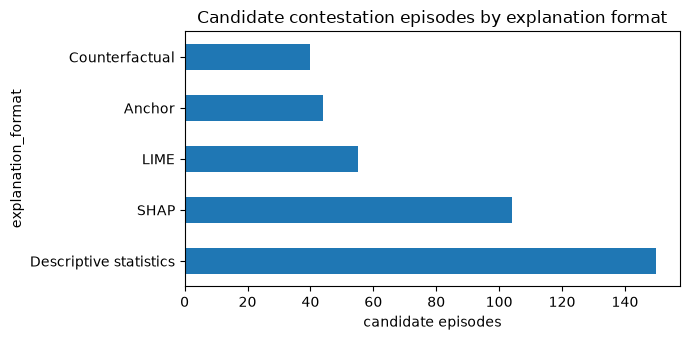


FEASIBILITY GATE - provisional (fill after manual review)
Candidate episodes total:            667
  on explanation slides (codeable):  393
  on context slides (excluded):      274
Participant groups represented:      3 / 3
Explanation formats represented:     5 / 5

DECISION RULE (from the proposal):
  If manual review confirms a sufficiently DIVERSE set of genuine
  contestation episodes across groups and formats -> keep 'contestation'
  as the central construct. If confirmed episodes are sparse -> widen
  scope to 'epistemic friction', retaining contestation as one category.

  >> Enter confirmed counts + verdict after coding
     feasibility_review_sample.csv, then port into main-2.tex Sec. 3.


In [23]:
# ============================================================
# 11. Gate summary: candidate counts + diversity + verdict scaffold
# ============================================================

# The per-format comparison uses explanation slides only.
expl = candidates[candidates["is_explanation_slide"]]

by_group = expl.groupby("participant_group").size().rename("candidates")
by_format = (expl.groupby("explanation_format").size()
             .reindex(FIVE_FORMATS).rename("candidates"))
cross = (pd.crosstab(expl["explanation_format"], expl["participant_group"])
         .reindex(FIVE_FORMATS))

print("Candidate contestation episodes on explanation slides, by group:")
display(by_group.to_frame())
print("By explanation format:")
display(by_format.to_frame())
print("Format x group (feeds Table tab:distribution):")
display(cross)
cross.to_csv(TABLE_OUTPUT_DIR / "candidates_format_by_group.csv")

if _HAVE_MPL and len(expl):
    ax = by_format.plot(kind="barh", figsize=(7, 3.5))
    ax.set_xlabel("candidate episodes")
    ax.set_title("Candidate contestation episodes by explanation format")
    plt.tight_layout()
    plt.savefig(FIGURE_OUTPUT_DIR / "candidates_by_format.png", dpi=150)
    plt.show()

print("\n" + "=" * 64)
print("FEASIBILITY GATE - provisional (fill after manual review)")
print("=" * 64)
print(f"Candidate episodes total:            {len(candidates)}")
print(f"  on explanation slides (codeable):  {len(expl)}")
print(f"  on context slides (excluded):      {len(candidates) - len(expl)}")
print(f"Participant groups represented:      {expl['participant_group'].nunique()} / 3")
print(f"Explanation formats represented:     {expl['explanation_format'].nunique()} / 5")
print("\nDECISION RULE (from the proposal):")
print("  If manual review confirms a sufficiently DIVERSE set of genuine")
print("  contestation episodes across groups and formats -> keep 'contestation'")
print("  as the central construct. If confirmed episodes are sparse -> widen")
print("  scope to 'epistemic friction', retaining contestation as one category.")
print("\n  >> Enter confirmed counts + verdict after coding")
print("     feasibility_review_sample.csv, then port into main-2.tex Sec. 3.")

In [24]:
# ============================================================
# 12. Persist audit artefacts
# ============================================================

transcripts.to_parquet(OUTPUT_DIR / "transcripts_annotated.parquet", index=False)

manifest = {
    "files": int(transcripts["__source_file"].nunique()),
    "participants": total_participants,
    "rows": len(transcripts),
    "translated_rows": int(transcripts["text_en"].notna().sum())
        if "text_en" in transcripts else 0,
    "lexical_candidates": int(transcripts["lexicon_candidate"].sum()),
    "candidate_episodes": len(candidates),
    "review_sample_size": len(review_sample),
}
pd.Series(manifest).to_json(OUTPUT_DIR / "audit_manifest.json", indent=2)
print("Audit manifest:")
for key, value in manifest.items():
    print(f"  {key:>20}: {value}")
LOGGER.info("Notebook 02 complete. Artefacts in %s", OUTPUT_DIR)

INFO | Notebook 02 complete. Artefacts in /Users/sabrimanai/software/uj/detecting-contestation-xai/outputs/02_translation_and_feasibility_audit


Audit manifest:
                 files: 38
          participants: 39
                  rows: 14835
       translated_rows: 14834
    lexical_candidates: 667
    candidate_episodes: 667
    review_sample_size: 88


## Next steps

1. **Install the translation stack** in the Jupyter env and run top-to-bottom so
   `text_en` is populated and `transcripts_bilingual.csv` is written.
2. **Code `feasibility_review_sample.csv`** by hand (two coders): mark
   `is_contestation` and, for positives, the five taxonomy fields. This is the
   evidence that fills Table `tab:distribution` and Section 5.1 of `main-2.tex`.
3. **Record the gate verdict** — genuine-episode counts and diversity — and decide
   contestation vs. epistemic friction *before* writing the definition/taxonomy.
4. If precision of the lexical signal is low, **iterate the markers** and the
   contestation-adjacent code set, then regenerate the sample. Keep the marker
   lists and code mapping in version control as part of the audit trail.